<a href="https://colab.research.google.com/github/rizkayantizakaria-cloud/Pemodelan_Simulasi/blob/main/LSTM_Hidrodinamika_Plastik_terjemahan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM untuk Prediksi Dinamika Limbah Plastik
## Berdasarkan Data Hidrodinamika — Contoh Data Sintetis

**Sebelum mulai:**
- Aktifkan GPU: **Runtime → Change runtime type → T4 GPU → Save**
- Jalankan setiap sel dengan **Shift + Enter** dari atas ke bawah

---
**Catatan:** Notebook ini menggunakan **data sintetis** yang dibuat berdasarkan pola fisik nyata:
- Siklus pasut semi-diurnal (2x per hari, periode ~12.4 jam)
- Siklus musiman (angin musim barat & timur)
- Korelasi realistis antara hidrodinamika dan konsentrasi plastik
- Noise acak untuk mensimulasikan variabilitas lapangan


## Sel 1 — Install & Import Library

In [2]:
# ============================================================
# INSTALASI DAN IMPORT LIBRARY
# ============================================================

# Menginstal library tambahan yang belum tersedia di Google Colab.
# Opsi --quiet digunakan agar proses instalasi tidak menampilkan
# terlalu banyak informasi di layar.
!pip install seaborn scikit-learn --quiet

# ============================================================
# IMPORT LIBRARY YANG DIGUNAKAN
# ============================================================

# Library untuk perhitungan numerik dan operasi array
import numpy as np

# Library untuk membaca, mengolah, dan memanipulasi data berbentuk tabel
import pandas as pd

# Library untuk membuat grafik visualisasi data
import matplotlib.pyplot as plt

# Library untuk mengatur tata letak beberapa grafik dalam satu tampilan
import matplotlib.gridspec as gridspec

# Library visualisasi statistik dengan tampilan yang lebih menarik
import seaborn as sns

# Library untuk mengatur atau menyembunyikan pesan peringatan (warning)
import warnings

# Library untuk mengakses dan mengelola file maupun folder
import os

# ============================================================
# IMPORT LIBRARY PREPROCESSING DAN EVALUASI MODEL
# ============================================================

# Digunakan untuk melakukan normalisasi data ke rentang 0 sampai 1
from sklearn.preprocessing import MinMaxScaler

# Mengimpor beberapa metrik evaluasi model
from sklearn.metrics import (
    mean_squared_error,            # Menghitung Mean Squared Error (MSE)
    mean_absolute_error,           # Menghitung Mean Absolute Error (MAE)
    r2_score,                      # Menghitung nilai koefisien determinasi (R²)
    mean_absolute_percentage_error # Menghitung Mean Absolute Percentage Error (MAPE)
)

# ============================================================
# IMPORT LIBRARY TENSORFLOW DAN KERAS
# ============================================================

# Mengimpor TensorFlow sebagai framework Deep Learning
import tensorflow as tf

# Mengimpor modul Keras yang terdapat di TensorFlow
from tensorflow import keras

# Mengimpor layer-layer dasar pada Keras
from tensorflow.keras import layers, models, callbacks

# Mengimpor layer yang digunakan dalam pembangunan model LSTM
from tensorflow.keras.layers import (
    LSTM,                 # Layer Long Short-Term Memory
    Dense,                # Layer Fully Connected
    Dropout,              # Layer untuk mengurangi overfitting
    Input,                # Layer input model
    Bidirectional,        # Layer LSTM dua arah
    LayerNormalization    # Layer normalisasi
)

# Mengimpor kelas Model untuk membangun arsitektur jaringan saraf
from tensorflow.keras.models import Model

# ============================================================
# PENGATURAN AWAL PROGRAM
# ============================================================

# Menyembunyikan pesan warning agar tampilan output lebih rapi
warnings.filterwarnings('ignore')

# Menentukan seed agar hasil random NumPy selalu sama
# setiap kali program dijalankan
np.random.seed(42)

# Menentukan seed TensorFlow agar proses pelatihan model
# dapat direproduksi kembali
tf.random.set_seed(42)

# ============================================================
# MENAMPILKAN INFORMASI SISTEM
# ============================================================

# Menampilkan garis pembatas
print('=' * 50)
print('  Konfigurasi Sistem')
print('=' * 50)

# Mengimpor library sys untuk mengetahui informasi Python
import sys

# Menampilkan versi Python yang digunakan
print(f'Python versi   : {sys.version.split()[0]}')

# Menampilkan versi TensorFlow
print(f'TensorFlow     : {tf.__version__}')

# Menampilkan versi NumPy
print(f'NumPy          : {np.__version__}')

# Menampilkan versi Pandas
print(f'Pandas         : {pd.__version__}')

# Mengecek apakah komputer memiliki GPU yang dapat digunakan
gpus = tf.config.list_physical_devices('GPU')

# Menampilkan status penggunaan GPU atau CPU
print(f'GPU tersedia   : {"YA — " + gpus[0].name if gpus else "TIDAK (CPU mode)"}')

# Menampilkan garis penutup
print('=' * 50)

  Konfigurasi Sistem
Python versi   : 3.12.13
TensorFlow     : 2.20.0
NumPy          : 2.0.2
Pandas         : 2.2.2
GPU tersedia   : TIDAK (CPU mode)


## Sel 2 — Buat Data Hidrodinamika Sintetis

Data dibuat berdasarkan formula fisik nyata:
- Pasut mengikuti superposisi gelombang M2 dan S2
- Arus dipengaruhi gradien pasut + angin musiman
- Konsentrasi plastik berkorelasi dengan kecepatan arus dan curah hujan

In [17]:
def buat_data_hidrodinamika(
    tanggal_mulai='2025-01-01',
    n_hari=365,
    resolusi_jam=1
):
    """
    Membuat dataset hidrodinamika sintetis realistis.

    Parameter:
    - tanggal_mulai : string 'YYYY-MM-DD'
    - n_hari        : jumlah hari data (default 365 = 1 tahun)
    - resolusi_jam  : interval data dalam jam (1 = per jam)

    Return:
    - df : DataFrame dengan semua variabel hidrodinamika
    """

    # Buat index waktu
    n_titik = n_hari * 24 // resolusi_jam
    waktu   = pd.date_range(
        start=tanggal_mulai,
        periods=n_titik,
        freq=f'{resolusi_jam}h'
    )
    t = np.arange(n_titik)  # indeks waktu integer

    print(f'Membuat {n_titik:,} baris data ({n_hari} hari, resolusi {resolusi_jam} jam)...')

    # ============================================================
    # 1. PASUT (Tidal Height)
    # Superposisi komponen M2 (12.42 jam) + S2 (12.00 jam)
    # + komponen K1 (23.93 jam) untuk pola diurnal
    # ============================================================
    T_M2  = 12.42  # periode komponen utama pasut (jam)
    T_S2  = 12.00  # komponen solar semi-diurnal
    T_K1  = 23.93  # komponen lunisolar diurnal

    noise_pasut   = np.random.normal(0, 0.05, n_titik)
    tinggi_pasut  = (
        1.20 * np.sin(2 * np.pi * t / T_M2) +
        0.45 * np.sin(2 * np.pi * t / T_S2 + np.pi/6) +
        0.25 * np.sin(2 * np.pi * t / T_K1) +
        noise_pasut
    )

    # ============================================================
    # 2. ARUS LAUT (U dan V komponen)
    # Arus utama driven by pasut + pengaruh angin musiman
    # ============================================================
    T_musim = 365.25 * 24  # periode musiman (jam)

    # Arus komponen U (timur-barat), dipengaruhi gradien pasut
    u_arus = (
        0.35 * np.cos(2 * np.pi * t / T_M2) +
        0.12 * np.cos(2 * np.pi * t / T_S2) +
        0.08 * np.sin(2 * np.pi * t / T_musim) +  # variasi musiman
        np.random.normal(0, 0.04, n_titik)
    )

    # Arus komponen V (utara-selatan)
    v_arus = (
        0.28 * np.sin(2 * np.pi * t / T_M2 + np.pi/4) +
        0.10 * np.sin(2 * np.pi * t / T_S2) +
        0.06 * np.cos(2 * np.pi * t / T_musim) +
        np.random.normal(0, 0.03, n_titik)
    )

    # Magnitude arus (resultant)
    mag_arus = np.sqrt(u_arus**2 + v_arus**2)

    # ============================================================
    # 3. GELOMBANG LAUT
    # Tinggi signifikan (Hs) dan periode puncak (Tp)
    # Lebih tinggi di musim barat (bulan 11-3)
    # ============================================================
    bulan = waktu.month.values

    # Faktor musim: musim barat lebih bergelombang
    faktor_musim = np.where(
        (bulan >= 11) | (bulan <= 3),
        1.8,   # musim barat
        1.0    # musim timur/peralihan
    )

    Hs = (
        faktor_musim * 0.6 *
        (1 + 0.3 * np.sin(2 * np.pi * t / (6 * 24))) +  # variasi 6 harian
        np.abs(np.random.normal(0, 0.15, n_titik))
    )
    Hs = np.clip(Hs, 0.05, 4.5)  # batas fisik realistis

    Tp = 4.5 + 2.5 * (Hs / Hs.max()) + np.random.normal(0, 0.5, n_titik)
    Tp = np.clip(Tp, 3.0, 14.0)

    # ============================================================
    # 4. ANGIN
    # Pola musim barat (NW) dan musim timur (SE) khas Indonesia
    # ============================================================
    kec_angin = (
        faktor_musim * 3.5 +
        1.5 * np.sin(2 * np.pi * t / (12 * 24)) +  # variasi diurnal angin darat-laut
        np.abs(np.random.normal(0, 0.8, n_titik))
    )
    kec_angin = np.clip(kec_angin, 0.5, 18.0)

    # Arah angin: musim barat ~315° (NW), musim timur ~135° (SE)
    arah_base = np.where(
        (bulan >= 11) | (bulan <= 3),
        315.0,  # musim barat
        135.0   # musim timur
    )
    arah_angin = (arah_base + np.random.normal(0, 25, n_titik)) % 360

    # Encoding sirkular arah angin
    angin_sin = np.sin(np.radians(arah_angin))
    angin_cos = np.cos(np.radians(arah_angin))

    # ============================================================
    # 5. CURAH HUJAN
    # Musim hujan (Nov-Mar), musim kemarau (Jun-Sep)
    # ============================================================
    intensitas_hujan = np.where(
        (bulan >= 11) | (bulan <= 3),
        0.4,   # peluang hujan lebih tinggi musim basah
        0.12   # peluang hujan lebih rendah musim kemarau
    )

    # Simulasi kejadian hujan diskrit
    kejadian_hujan = np.random.random(n_titik) < intensitas_hujan / resolusi_jam
    curah_hujan = np.where(
        kejadian_hujan,
        np.abs(np.random.exponential(8.0, n_titik)),  # intensitas eksponensial
        0.0
    )
    # Akumulasi hujan menjadi sedikit lebih smooth
    curah_hujan = pd.Series(curah_hujan).rolling(3, min_periods=1).mean().values

    # ============================================================
    # 6. KONSENTRASI PLASTIK (TARGET)
    # Dipengaruhi oleh: arus kuat, hujan deras, pasut rendah
    # + tren musiman + noise acak lapangan
    # ============================================================

    # Base: konsentrasi rata-rata ~250 partikel/m³
    base_plastik = 250.0

    # Kontribusi setiap faktor
    efek_arus    = 180 * mag_arus               # arus kuat mobilisasi plastik
    efek_hujan   = 25  * np.log1p(curah_hujan)  # hujan bawa plastik dari daratan
    efek_pasut   = -60 * tinggi_pasut           # pasut tinggi = pengenceran
    efek_musim   = 80  * np.sin(2 * np.pi * t / T_musim + np.pi)  # puncak di musim hujan
    efek_gelombang = 30 * Hs                    # gelombang aduk plastik permukaan

    # Lag effect: plastik tidak langsung muncul saat hujan (delay 3-6 jam)
    lag_hujan = pd.Series(efek_hujan).shift(4).fillna(0).values

       # Menggabungkan seluruh faktor yang memengaruhi
    # konsentrasi plastik di laut
    konsentrasi_plastik = (
        base_plastik +
        efek_arus +
        lag_hujan +
        efek_pasut +
        efek_musim +
        efek_gelombang +
        np.random.normal(0, 30, n_titik)  # Menambahkan noise acak agar data lebih realistis
    )

    # Membatasi nilai konsentrasi plastik agar tidak bernilai negatif
    konsentrasi_plastik = np.clip(konsentrasi_plastik, 10.0, 1200.0)

    # ============================================================
    # 7. MEMBUAT FITUR WAKTU
    # ============================================================

    # Mengambil informasi jam dan bulan dari indeks waktu
    jam = waktu.hour.values
    bulan_val = waktu.month.values

    # Mengubah informasi jam menjadi bentuk sinus dan cosinus
    # agar pola waktu bersifat sirkular dan mudah dipelajari model
    jam_sin = np.sin(2 * np.pi * jam / 24)
    jam_cos = np.cos(2 * np.pi * jam / 24)

    # Mengubah informasi bulan menjadi bentuk sinus dan cosinus
    # untuk merepresentasikan pola musiman
    bulan_sin = np.sin(2 * np.pi * bulan_val / 12)
    bulan_cos = np.cos(2 * np.pi * bulan_val / 12)

    # ============================================================
    # 8. MENYUSUN DATA KE DALAM DATAFRAME
    # ============================================================

    # Menggabungkan seluruh variabel hidrodinamika
    # ke dalam sebuah DataFrame
    df = pd.DataFrame({
        'datetime'             : waktu,
        'tinggi_pasut'         : np.round(tinggi_pasut, 3),
        'u_arus'               : np.round(u_arus, 4),
        'v_arus'               : np.round(v_arus, 4),
        'mag_arus'             : np.round(mag_arus, 4),
        'Hs_gelombang'         : np.round(Hs, 3),
        'Tp_gelombang'         : np.round(Tp, 2),
        'kec_angin'            : np.round(kec_angin, 2),
        'arah_angin'           : np.round(arah_angin, 1),
        'angin_sin'            : np.round(angin_sin, 4),
        'angin_cos'            : np.round(angin_cos, 4),
        'curah_hujan'          : np.round(curah_hujan, 2),
        'jam_sin'              : np.round(jam_sin, 4),
        'jam_cos'              : np.round(jam_cos, 4),
        'bulan_sin'            : np.round(bulan_sin, 4),
        'bulan_cos'            : np.round(bulan_cos, 4),
        'konsentrasi_plastik'  : np.round(konsentrasi_plastik, 2),
    })

    # Menjadikan kolom datetime sebagai indeks DataFrame
    # agar data tersusun berdasarkan waktu
    df = df.set_index('datetime')

    # Mengembalikan DataFrame sebagai hasil fungsi
    return df


# ============================================================
# MEMBUAT DATASET HIDRODINAMIKA
# ============================================================

# Membuat dataset hidrodinamika sintetis
df = buat_data_hidrodinamika(
    tanggal_mulai='2025-01-01',
    n_hari=365,
    resolusi_jam=1
)

# ============================================================
# MENGUBAH DATA MENJADI DATA MINGGUAN
# ============================================================

# Menghitung nilai rata-rata setiap minggu
df_mingguan = df.resample('W').mean()

# Menambahkan nomor minggu
df_mingguan['minggu_ke'] = range(1, len(df_mingguan) + 1)

# ============================================================
# MENYIMPAN DATASET
# ============================================================

# Menyimpan data harian
df.to_csv('data_hidrodinamika_sintetis.csv')

# Menyimpan data mingguan
df_mingguan.to_csv('data_hidrodinamika_mingguan.csv')

# ============================================================
# MENAMPILKAN INFORMASI DATASET
# ============================================================

print('\nDataset berhasil dibuat!')

print(f'Data harian   : {df.shape[0]:,} baris')

print(f'Data mingguan : {df_mingguan.shape[0]} minggu')

print(f'Jumlah kolom  : {df_mingguan.shape[1]}')

print(f'Periode       : {df_mingguan.index[0].date()} sampai {df_mingguan.index[-1].date()}')

print(f'Missing values: {df_mingguan.isnull().sum().sum()}')

print('\nLima minggu pertama')

print(df_mingguan.head().to_string())

Membuat 8,760 baris data (365 hari, resolusi 1 jam)...

Dataset berhasil dibuat!
Data harian   : 8,760 baris
Data mingguan : 53 minggu
Jumlah kolom  : 17
Periode       : 2025-01-05 sampai 2026-01-04
Missing values: 0

Lima minggu pertama
            tinggi_pasut    u_arus    v_arus  mag_arus  Hs_gelombang  Tp_gelombang  kec_angin  arah_angin  angin_sin  angin_cos  curah_hujan       jam_sin  jam_cos  bulan_sin  bulan_cos  konsentrasi_plastik  minggu_ke
datetime                                                                                                                                                                                                                 
2025-01-05      0.031350 -0.002812  0.067096  0.388962      1.240667      6.208833   8.052583  304.459167  -0.623066   0.659046     3.002583  4.625929e-19      0.0   0.500000   0.866000           373.099250          1
2025-01-12     -0.020631  0.016993  0.059677  0.256055      1.174696      6.064167   6.172440  296.038690  -

## Sel 3 — Statistik Deskriptif

In [18]:
# ============================================================
# MENAMPILKAN STATISTIK DESKRIPTIF DATASET
# ============================================================

# Menampilkan judul statistik deskriptif dataset hidrodinamika
print('Statistik Deskriptif Dataset Hidrodinamika:')
print('=' * 70)

# Menghitung statistik deskriptif setiap variabel
# kemudian mentransposisikannya agar lebih mudah dibaca
stats = df.describe().T

# Menghitung rentang nilai (range),
# yaitu selisih antara nilai maksimum dan minimum
stats['range'] = stats['max'] - stats['min']

# Menampilkan nilai rata-rata, standar deviasi,
# nilai minimum, maksimum, dan rentang setiap variabel
print(stats[['mean', 'std', 'min', 'max', 'range']].round(3).to_string())

# ============================================================
# MENAMPILKAN KORELASI FITUR DENGAN TARGET
# ============================================================

# Menampilkan judul analisis korelasi
print('\nKorelasi dengan Konsentrasi Plastik (Target):')
print('-' * 40)

# Menghitung nilai korelasi setiap variabel
# terhadap variabel target (konsentrasi plastik),
# kemudian mengurutkannya dari yang terbesar
korelasi = df.corr()['konsentrasi_plastik'].sort_values(ascending=False)

# Menampilkan nilai korelasi setiap fitur
# beserta visualisasi sederhana menggunakan karakter '#'
for fitur, nilai in korelasi.items():

    # Melewati variabel target agar tidak dibandingkan dengan dirinya sendiri
    if fitur != 'konsentrasi_plastik':

        # Membuat panjang batang berdasarkan besar nilai korelasi
        bar = '#' * int(abs(nilai) * 20)

        # Menentukan tanda positif atau negatif korelasi
        arah = '+' if nilai >= 0 else '-'

        # Menampilkan nama fitur, nilai korelasi,
        # serta diagram batang sederhana
        print(f'  {fitur:25s}: {arah}{abs(nilai):.3f}  {bar}')

Statistik Deskriptif Dataset Hidrodinamika:
                        mean     std     min      max    range
tinggi_pasut          -0.001   0.922  -1.976    1.976    3.952
u_arus                 0.000   0.270  -0.622    0.637    1.260
v_arus                 0.000   0.217  -0.477    0.508    0.985
mag_arus               0.323   0.125   0.001    0.695    0.693
Hs_gelombang           0.916   0.308   0.420    1.865    1.445
Tp_gelombang           5.736   0.649   3.640    7.980    4.340
kec_angin              5.314   1.820   2.010   10.430    8.420
arah_angin           204.069  93.095   0.100  359.800  359.700
angin_sin              0.112   0.698  -1.000    1.000    2.000
angin_cos             -0.110   0.698  -1.000    1.000    2.000
curah_hujan            1.920   3.109   0.000   30.360   30.360
jam_sin                0.000   0.707  -1.000    1.000    2.000
jam_cos               -0.000   0.707  -1.000    1.000    2.000
bulan_sin             -0.005   0.706  -1.000    1.000    2.000
bulan_cos  

## Sel 4 — Visualisasi Data (EDA)

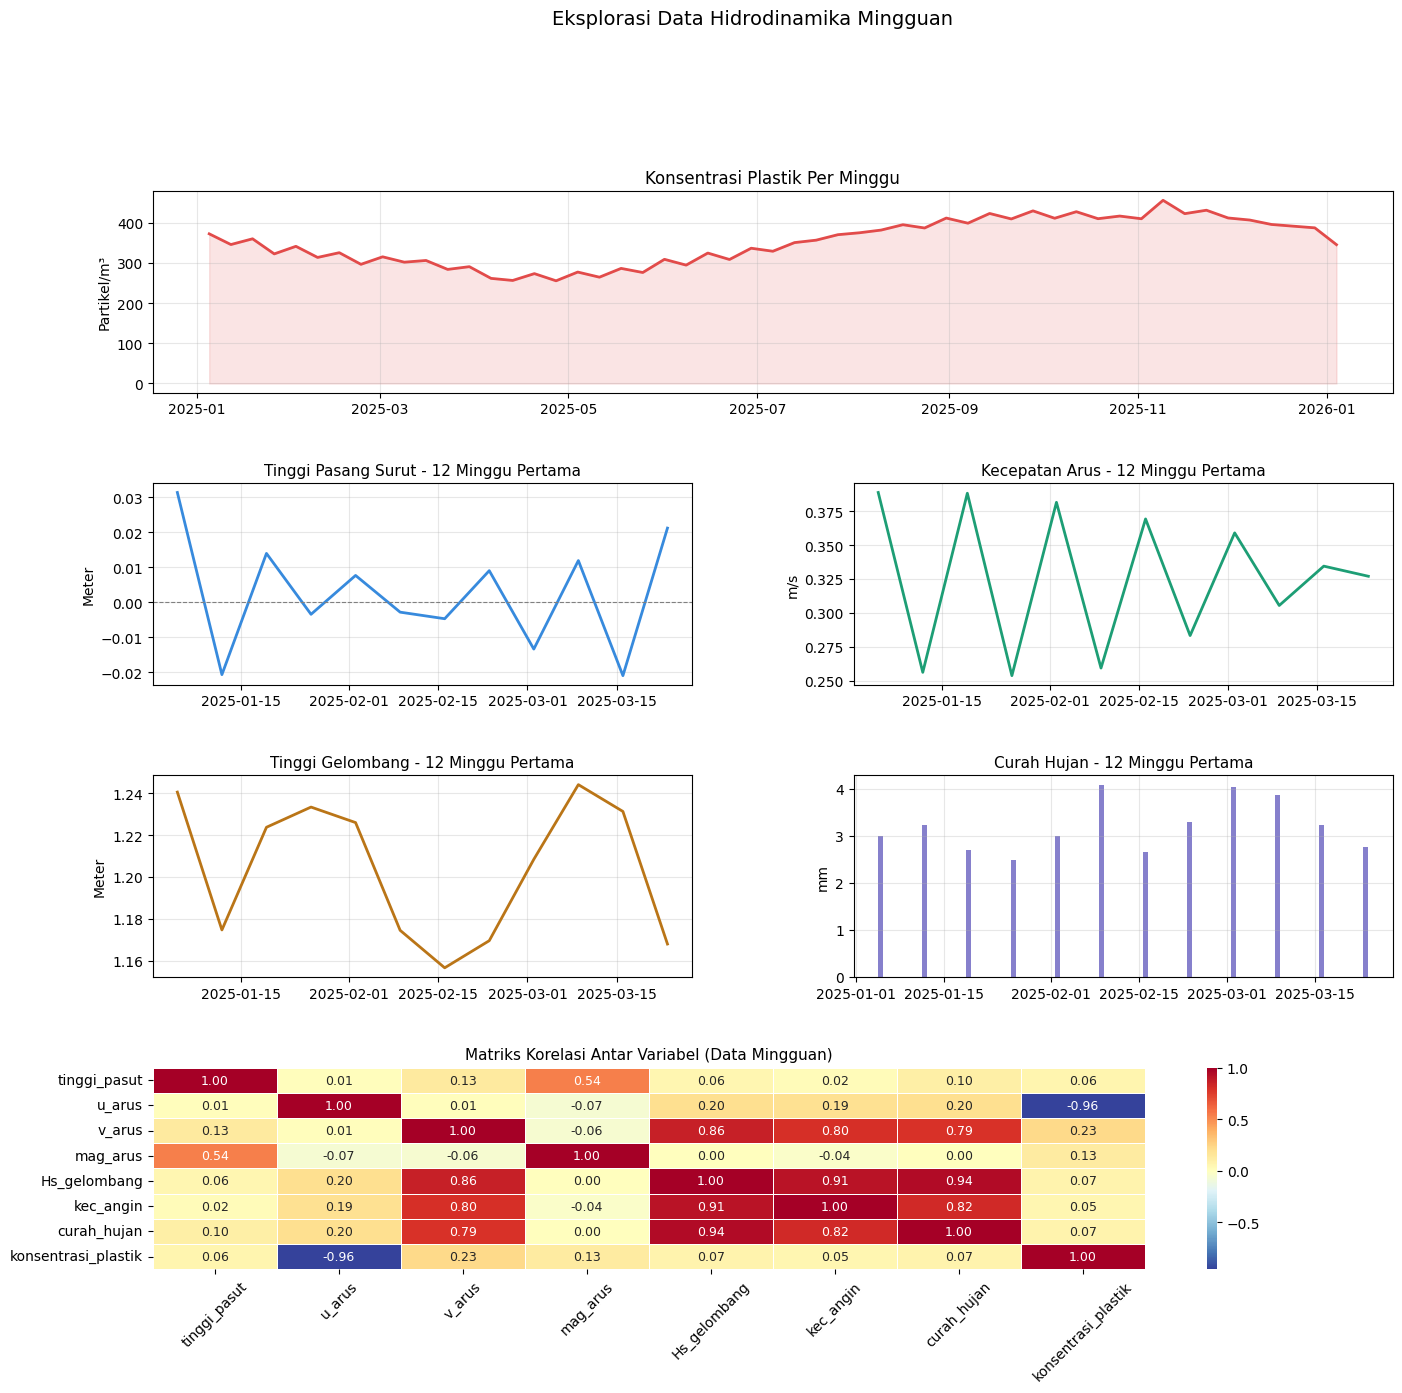

Visualisasi EDA data mingguan selesai!


In [19]:
# ============================================================
# MEMBUAT VISUALISASI EXPLORATORY DATA ANALYSIS (EDA)
# DATA HIDRODINAMIKA MINGGUAN
# ============================================================

# Membuat kanvas gambar dengan ukuran 16 × 14 inci
fig = plt.figure(figsize=(16, 14))

# Membuat tata letak grafik menggunakan GridSpec
# yang terdiri dari 4 baris dan 2 kolom
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

# Mengambil data 12 minggu pertama
# agar perubahan data lebih mudah diamati
df_12 = df_mingguan.iloc[:12]

# ============================================================
# 1. GRAFIK KONSENTRASI PLASTIK PER MINGGU
# ============================================================

# Membuat area grafik pertama
ax1 = fig.add_subplot(gs[0, :])

# Menampilkan grafik konsentrasi plastik mingguan
ax1.plot(
    df_mingguan.index,
    df_mingguan['konsentrasi_plastik'],
    color='#E24B4A',
    lw=2
)

# Memberikan warna pada area di bawah grafik
ax1.fill_between(
    df_mingguan.index,
    df_mingguan['konsentrasi_plastik'],
    alpha=0.15,
    color='#E24B4A'
)

# Memberikan judul grafik
ax1.set_title('Konsentrasi Plastik Per Minggu', fontsize=12)

# Memberikan label sumbu Y
ax1.set_ylabel('Partikel/m³')

# Menampilkan grid
ax1.grid(True, alpha=0.3)

# ============================================================
# 2. GRAFIK TINGGI PASANG SURUT 12 MINGGU PERTAMA
# ============================================================

# Membuat area grafik kedua
ax2 = fig.add_subplot(gs[1, 0])

# Menampilkan grafik tinggi pasang surut
ax2.plot(
    df_12.index,
    df_12['tinggi_pasut'],
    color='#378ADD',
    lw=2
)

# Menambahkan garis nol sebagai acuan
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Memberikan judul grafik
ax2.set_title('Tinggi Pasang Surut - 12 Minggu Pertama', fontsize=11)

# Memberikan label sumbu Y
ax2.set_ylabel('Meter')

# Menampilkan grid
ax2.grid(True, alpha=0.3)

# ============================================================
# 3. GRAFIK KECEPATAN ARUS 12 MINGGU PERTAMA
# ============================================================

# Membuat area grafik ketiga
ax3 = fig.add_subplot(gs[1, 1])

# Menampilkan grafik kecepatan arus
ax3.plot(
    df_12.index,
    df_12['mag_arus'],
    color='#1D9E75',
    lw=2
)

# Memberikan judul grafik
ax3.set_title('Kecepatan Arus - 12 Minggu Pertama', fontsize=11)

# Memberikan label sumbu Y
ax3.set_ylabel('m/s')

# Menampilkan grid
ax3.grid(True, alpha=0.3)

# ============================================================
# 4. GRAFIK TINGGI GELOMBANG 12 MINGGU PERTAMA
# ============================================================

# Membuat area grafik keempat
ax4 = fig.add_subplot(gs[2, 0])

# Menampilkan grafik tinggi gelombang
ax4.plot(
    df_12.index,
    df_12['Hs_gelombang'],
    color='#BA7517',
    lw=2
)

# Memberikan judul grafik
ax4.set_title('Tinggi Gelombang - 12 Minggu Pertama', fontsize=11)

# Memberikan label sumbu Y
ax4.set_ylabel('Meter')

# Menampilkan grid
ax4.grid(True, alpha=0.3)

# ============================================================
# 5. GRAFIK CURAH HUJAN 12 MINGGU PERTAMA
# ============================================================

# Membuat area grafik kelima
ax5 = fig.add_subplot(gs[2, 1])

# Menampilkan grafik batang curah hujan mingguan
ax5.bar(
    df_12.index,
    df_12['curah_hujan'],
    color='#534AB7',
    alpha=0.7
)

# Memberikan judul grafik
ax5.set_title('Curah Hujan - 12 Minggu Pertama', fontsize=11)

# Memberikan label sumbu Y
ax5.set_ylabel('mm')

# Menampilkan grid
ax5.grid(True, alpha=0.3)

# ============================================================
# 6. HEATMAP KORELASI ANTAR VARIABEL
# ============================================================

# Membuat area grafik keenam
ax6 = fig.add_subplot(gs[3, :])

# Menentukan variabel yang akan dihitung korelasinya
fitur_korelasi = [
    'tinggi_pasut',
    'u_arus',
    'v_arus',
    'mag_arus',
    'Hs_gelombang',
    'kec_angin',
    'curah_hujan',
    'konsentrasi_plastik'
]

# Menghitung matriks korelasi dari data mingguan
corr_matrix = df_mingguan[fitur_korelasi].corr()

# Menampilkan heatmap korelasi
sns.heatmap(
    corr_matrix,
    ax=ax6,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    annot_kws={'size':9}
)

# Memberikan judul heatmap
ax6.set_title('Matriks Korelasi Antar Variabel (Data Mingguan)', fontsize=11)

# Memutar label sumbu X
ax6.tick_params(axis='x', rotation=45)

# ============================================================
# MENAMPILKAN DAN MENYIMPAN HASIL VISUALISASI
# ============================================================

# Memberikan judul utama pada seluruh grafik
plt.suptitle(
    'Eksplorasi Data Hidrodinamika Mingguan',
    fontsize=14,
    y=1.01
)

# Menyimpan hasil visualisasi
plt.savefig(
    'eda_hidrodinamika_mingguan.png',
    bbox_inches='tight',
    dpi=150
)

# Menampilkan seluruh grafik
plt.show()

# Menampilkan pesan bahwa visualisasi telah selesai
print('Visualisasi EDA data mingguan selesai!')

## Sel 5 — Preprocessing: Normalisasi & Sliding Window

In [21]:
# ============================================================
# MENENTUKAN FITUR INPUT DAN TARGET
# ============================================================

# Menentukan variabel yang digunakan sebagai fitur input model
FITUR_INPUT = [
    'tinggi_pasut',
    'u_arus',
    'v_arus',
    'mag_arus',
    'Hs_gelombang',
    'Tp_gelombang',
    'kec_angin',
    'angin_sin',
    'angin_cos',
    'curah_hujan',
    'konsentrasi_plastik'   # Digunakan sebagai input autoregressive
]

# Menentukan variabel target yang akan diprediksi
TARGET = 'konsentrasi_plastik'

# ============================================================
# MENENTUKAN PARAMETER SLIDING WINDOW
# ============================================================

# Menggunakan data 4 minggu terakhir sebagai input
WINDOW = 4

# Memprediksi konsentrasi plastik untuk 1 minggu berikutnya
HORIZON = 1

print(f'Jumlah fitur input : {len(FITUR_INPUT)} variabel')
print(f'Window size        : {WINDOW} minggu')
print(f'Horizon            : {HORIZON} minggu')

# ============================================================
# NORMALISASI DATA MENGGUNAKAN MIN-MAX SCALER
# ============================================================

# Membuat scaler untuk data input
scaler_X = MinMaxScaler(feature_range=(0, 1))

# Membuat scaler untuk data target
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Mengambil data dari dataset mingguan
X_data = df_mingguan[FITUR_INPUT].values
y_data = df_mingguan[[TARGET]].values

# Melakukan normalisasi data input
X_scaled = scaler_X.fit_transform(X_data)

# Melakukan normalisasi data target
y_scaled = scaler_y.fit_transform(y_data)

print('\nRentang data setelah normalisasi')

print(f'Input  : {X_scaled.min():.4f} - {X_scaled.max():.4f}')
print(f'Target : {y_scaled.min():.4f} - {y_scaled.max():.4f}')

# ============================================================
# MEMBUAT DATA SEQUENCE UNTUK MODEL LSTM
# ============================================================

def buat_sequences(X, y, window, horizon):
    """
    Mengubah data deret waktu menjadi pasangan data input
    dan target yang siap digunakan oleh model LSTM.

    Input  : (jumlah_sampel, window, jumlah_fitur)
    Output : (jumlah_sampel, horizon)
    """

    Xs = []
    ys = []

    total = len(X) - window - horizon + 1

    for i in range(total):

        # Menyimpan data input sejumlah window minggu
        Xs.append(X[i:i + window])

        # Menyimpan target prediksi minggu berikutnya
        ys.append(y[i + window:i + window + horizon, 0])

    return np.array(Xs), np.array(ys)

# Membentuk sequence data
X_seq, y_seq = buat_sequences(
    X_scaled,
    y_scaled,
    WINDOW,
    HORIZON
)

print('\nUkuran sequence')

print(f'X_seq : {X_seq.shape}')
print(f'y_seq : {y_seq.shape}')

# ============================================================
# MEMBAGI DATA MENJADI TRAINING, VALIDATION, DAN TESTING
# ============================================================

n = len(X_seq)

n_train = int(n * 0.70)

n_val = int(n * 0.15)

X_train = X_seq[:n_train]
y_train = y_seq[:n_train]

X_val = X_seq[n_train:n_train + n_val]
y_val = y_seq[n_train:n_train + n_val]

X_test = X_seq[n_train + n_val:]
y_test = y_seq[n_train + n_val:]

print('\nPembagian Dataset')

print(f'Training   : {X_train.shape[0]} sampel')

print(f'Validation : {X_val.shape[0]} sampel')

print(f'Testing    : {X_test.shape[0]} sampel')

Jumlah fitur input : 11 variabel
Window size        : 4 minggu
Horizon            : 1 minggu

Rentang data setelah normalisasi
Input  : 0.0000 - 1.0000
Target : 0.0000 - 1.0000

Ukuran sequence
X_seq : (49, 4, 11)
y_seq : (49, 1)

Pembagian Dataset
Training   : 34 sampel
Validation : 7 sampel
Testing    : 8 sampel


## Sel 6 — Bangun Model LSTM

In [23]:
# ============================================================
# MEMBANGUN MODEL LSTM UNTUK PREDIKSI KONSENTRASI PLASTIK
# BERDASARKAN DATA HIDRODINAMIKA MINGGUAN
# ============================================================

def build_lstm_hidrodinamika(n_fitur, window, horizon):
    """
    Membangun arsitektur Bidirectional LSTM
    untuk memprediksi konsentrasi plastik mingguan.

    Arsitektur:
    Input
        ↓
    Bidirectional LSTM (32 unit)
        ↓
    Layer Normalization
        ↓
    LSTM (16 unit)
        ↓
    Layer Normalization
        ↓
    LSTM (8 unit)
        ↓
    Dropout
        ↓
    Dense (16)
        ↓
    Dense (8)
        ↓
    Output
    """

    # Input
    inp = Input(
        shape=(window, n_fitur),
        name='input_hidrodinamika'
    )

    # ============================================================
    # LAYER 1
    # ============================================================

    x = Bidirectional(
        LSTM(
            32,
            return_sequences=True,
            dropout=0.10,
            recurrent_dropout=0.05
        ),
        name='bilstm_1'
    )(inp)

    x = LayerNormalization(name='ln_1')(x)

    # ============================================================
    # LAYER 2
    # ============================================================

    x = LSTM(
        16,
        return_sequences=True,
        dropout=0.10,
        name='lstm_2'
    )(x)

    x = LayerNormalization(name='ln_2')(x)

    # ============================================================
    # LAYER 3
    # ============================================================

    x = LSTM(
        8,
        return_sequences=False,
        dropout=0.10,
        name='lstm_3'
    )(x)

    x = Dropout(
        0.20,
        name='dropout_1'
    )(x)

    # ============================================================
    # FULLY CONNECTED
    # ============================================================

    x = Dense(
        16,
        activation='relu',
        name='dense_1'
    )(x)

    x = Dropout(
        0.10,
        name='dropout_2'
    )(x)

    x = Dense(
        8,
        activation='relu',
        name='dense_2'
    )(x)

    # ============================================================
    # OUTPUT
    # ============================================================

    output = Dense(
        horizon,
        activation='linear',
        name='output_prediksi'
    )(x)

    model = Model(
        inputs=inp,
        outputs=output,
        name='LSTM_Hidrodinamika_Mingguan'
    )

    return model


# ============================================================
# MEMBANGUN MODEL
# ============================================================

n_fitur = X_train.shape[2]

model = build_lstm_hidrodinamika(
    n_fitur,
    WINDOW,
    HORIZON
)

# ============================================================
# MENGOMPILASI MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae']
)

# ============================================================
# MENAMPILKAN INFORMASI MODEL
# ============================================================

print("Arsitektur Model LSTM")
print("=" * 65)

model.summary()

print("=" * 65)

total_params = model.count_params()

print(f"\nTotal parameter : {total_params:,}")
print(f"Jumlah fitur    : {n_fitur}")
print(f"Window          : {WINDOW} minggu")
print(f"Horizon         : {HORIZON} minggu")

Arsitektur Model LSTM


Model: "LSTM_Hidrodinamika_Mingguan"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_hidrodinamika             │ (None, 4, 11)          │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 4, 64)          │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_1 (LayerNormalization)       │ (None, 4, 64)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 4, 16)          │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_2 (LayerNormalization)       │ (None, 4, 16)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_prediksi (Dense)         │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,697 (69.13 KB)

 Trainable params: 17,697 (69.13 KB)

 Non-trainable params: 0 (0.00 B)


Total parameter : 17,697
Jumlah fitur    : 11
Window          : 4 minggu
Horizon         : 1 minggu


## Sel 7 — Training Model

In [25]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

# Mengimpor library untuk menghitung waktu proses pelatihan
import time

# ============================================================
# CALLBACKS SELAMA PROSES TRAINING
# ============================================================

cb_list = [

    # Menghentikan training secara otomatis apabila
    # nilai validation loss tidak membaik selama 10 epoch
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Menurunkan learning rate apabila validation loss stagnan
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    # Menyimpan model dengan performa terbaik
    keras.callbacks.ModelCheckpoint(
        filepath='lstm_hidrodinamika_mingguan_terbaik.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

# ============================================================
# PARAMETER TRAINING
# ============================================================

# Jumlah data yang diproses setiap iterasi
BATCH_SIZE = 8

# Jumlah maksimum epoch pelatihan
EPOCHS = 100

print('Memulai proses pelatihan model LSTM')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Maksimum epoch  : {EPOCHS}')
print(f'Data training   : {len(X_train)} sampel')
print('=' * 55)

# ============================================================
# PROSES TRAINING MODEL
# ============================================================

# Mencatat waktu mulai training
start = time.time()

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=cb_list,

    verbose=1,

    # Data time series tidak boleh diacak
    shuffle=False
)

# ============================================================
# MENAMPILKAN HASIL TRAINING
# ============================================================

# Menghitung lama proses training
elapsed = time.time() - start

# Menentukan epoch terbaik
best_epoch = np.argmin(history.history['val_loss']) + 1

# Mengambil validation loss terbaik
best_val = min(history.history['val_loss'])

print('\n' + '=' * 55)

print(f'Training selesai dalam {elapsed/60:.2f} menit')

print(f'Epoch terbaik        : {best_epoch}')

print(f'Validation Loss      : {best_val:.6f}')

Memulai proses pelatihan model LSTM
Batch size      : 8
Maksimum epoch  : 100
Data training   : 34 sampel
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0135 - mae: 0.1200

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0205 - mae: 0.1468 - val_loss: 0.0199 - val_mae: 0.1810 - learning_rate: 1.2500e-04
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0118 - mae: 0.1293

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0131 - mae: 0.1321 - val_loss: 0.0188 - val_mae: 0.1752 - learning_rate: 1.2500e-04
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0090 - mae: 0.1076

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0106 - mae: 0.1165 - val_loss: 0.0182 - val_mae: 0.1719 - learning_rate: 1.2500e-04
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0175 - mae: 0.1545

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0217 - mae: 0.1716 - val_loss: 0.0181 - val_mae: 0.1712 - learning_rate: 1.2500e-04
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0125 - mae: 0.1263

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0091 - mae: 0.1073 - val_loss: 0.0121 - val_mae: 0.1309 - learning_rate: 1.2500e-04
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0099 - mae: 0.1210

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.0119 - mae: 0.1310 - val_loss: 0.0110 - val_mae: 0.1224 - learning_rate: 1.2500e-04
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0088 - mae: 0.1040 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0106 - mae: 0.1151 - val_loss: 0.0103 - val_mae: 0.1160 - learning_rate: 1.2500e-04
Epoch 16/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0118 - mae: 0.1299 - val_loss: 0.0103 - val_mae: 0.1164 - learning_rate: 1.2500e-04
Epoch 17/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0147 - mae: 0.1419 - val_loss: 0.0106 - val_mae: 0.1182 - learning_rate: 1.2500e-04
Epoch 18/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0144 - mae: 0.1432 - val_loss: 0.0105 - val_mae: 0.1175 - learning_rate: 1.2500e-04
Epoch 19/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0101 - mae: 0.1168 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0130 - mae: 0.1324 - val_loss: 0.0098 - val_mae: 0.1122 - learning_rate: 1.2500e-04
Epoch 20/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0146 - mae: 0.1406

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0178 - mae: 0.1575 - val_loss: 0.0094 - val_mae: 0.1087 - learning_rate: 1.2500e-04
Epoch 21/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0151 - mae: 0.1431 - val_loss: 0.0096 - val_mae: 0.1113 - learning_rate: 1.2500e-04
Epoch 22/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0100 - mae: 0.1195 - val_loss: 0.0103 - val_mae: 0.1167 - learning_rate: 1.2500e-04
Epoch 23/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0329 - mae: 0.1878 - val_loss: 0.0114 - val_mae: 0.1260 - learning_rate: 1.2500e-04
Epoch 24/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0143 - mae: 0.1259 - val_loss: 0.0120 - val_mae: 0.1305 - learning_rate: 1.2500e-04
Epoch 25/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0094 - mae: 0.1072
Epoch 25: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0110 - mae: 0.1208 - val_loss: 0.0125 - val_mae: 0.1339 - learning_rate: 1.2500e-04


## Sel 8 — Grafik Hasil Training

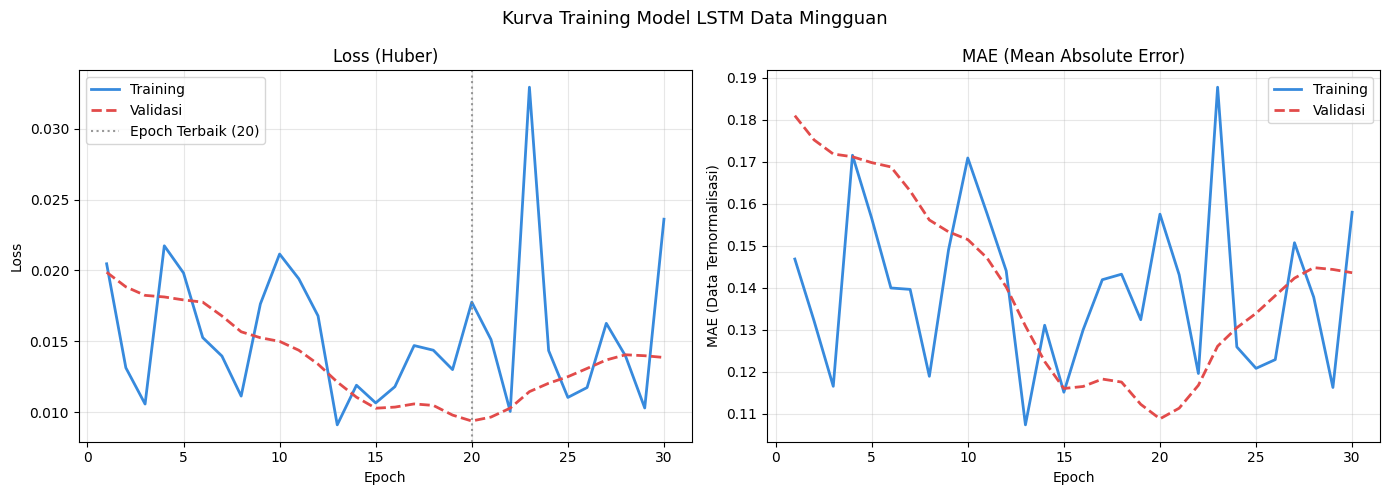

Visualisasi kurva training data mingguan selesai!


In [27]:
# ============================================================
# VISUALISASI HASIL TRAINING MODEL LSTM
# ============================================================

# Membuat kanvas dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Membuat urutan nomor epoch
ep = range(1, len(history.history['loss']) + 1)

# ============================================================
# 1. GRAFIK LOSS
# ============================================================

# Menampilkan loss data training
axes[0].plot(
    ep,
    history.history['loss'],
    label='Training',
    color='#378ADD',
    linewidth=2
)

# Menampilkan loss data validasi
axes[0].plot(
    ep,
    history.history['val_loss'],
    label='Validasi',
    color='#E24B4A',
    linewidth=2,
    linestyle='--'
)

# Menampilkan garis vertikal pada epoch terbaik
axes[0].axvline(
    best_epoch,
    color='gray',
    linestyle=':',
    alpha=0.8,
    label=f'Epoch Terbaik ({best_epoch})'
)

# Memberikan judul grafik
axes[0].set_title('Loss (Huber)', fontsize=12)

# Memberikan label sumbu
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# Menampilkan legenda
axes[0].legend()

# Menampilkan grid
axes[0].grid(True, alpha=0.3)

# ============================================================
# 2. GRAFIK MAE
# ============================================================

# Menampilkan MAE data training
axes[1].plot(
    ep,
    history.history['mae'],
    label='Training',
    color='#378ADD',
    linewidth=2
)

# Menampilkan MAE data validasi
axes[1].plot(
    ep,
    history.history['val_mae'],
    label='Validasi',
    color='#E24B4A',
    linewidth=2,
    linestyle='--'
)

# Memberikan judul grafik
axes[1].set_title('MAE (Mean Absolute Error)', fontsize=12)

# Memberikan label sumbu
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (Data Ternormalisasi)')

# Menampilkan legenda
axes[1].legend()

# Menampilkan grid
axes[1].grid(True, alpha=0.3)

# ============================================================
# MENAMPILKAN DAN MENYIMPAN GRAFIK
# ============================================================

# Memberikan judul utama
plt.suptitle(
    'Kurva Training Model LSTM Data Mingguan',
    fontsize=13
)

# Mengatur tata letak grafik
plt.tight_layout()

# Menyimpan grafik ke file gambar
plt.savefig(
    'kurva_training_mingguan.png',
    dpi=150,
    bbox_inches='tight'
)

# Menampilkan grafik
plt.show()

# Menampilkan pesan bahwa proses visualisasi selesai
print('Visualisasi kurva training data mingguan selesai!')

## Sel 9 — Evaluasi pada Data Test

In [29]:
# ============================================================
# MELAKUKAN PREDIKSI PADA DATA TESTING
# ============================================================

# Melakukan prediksi menggunakan model LSTM
y_pred_scaled = model.predict(
    X_test,
    verbose=0
)

# Mengembalikan hasil prediksi ke skala asli
# (satuan partikel per meter kubik)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Mengembalikan data target sebenarnya ke skala asli
y_true = scaler_y.inverse_transform(y_test)

# ============================================================
# MENGHITUNG METRIK EVALUASI
# ============================================================

# Mengubah array menjadi satu dimensi
y_pred_flat = y_pred.flatten()
y_true_flat = y_true.flatten()

# Menghitung Root Mean Square Error
rmse = np.sqrt(
    mean_squared_error(
        y_true_flat,
        y_pred_flat
    )
)

# Menghitung Mean Absolute Error
mae = mean_absolute_error(
    y_true_flat,
    y_pred_flat
)

# Menghitung Koefisien Determinasi
r2 = r2_score(
    y_true_flat,
    y_pred_flat
)

# Menghitung Mean Absolute Percentage Error
mape = (
    mean_absolute_percentage_error(
        y_true_flat,
        y_pred_flat
    ) * 100
)

# ============================================================
# MENAMPILKAN HASIL EVALUASI MODEL
# ============================================================

print('=' * 55)
print('      HASIL EVALUASI MODEL LSTM')
print('      Data Testing Mingguan')
print('=' * 55)

print(f'RMSE  : {rmse:.2f} partikel/m³')
print(f'MAE   : {mae:.2f} partikel/m³')
print(f'MAPE  : {mape:.2f}%')
print(f'R²    : {r2:.4f}')

print('=' * 55)

# ============================================================
# INTERPRETASI NILAI R²
# ============================================================

if r2 >= 0.90:
    ket = 'Sangat Baik'

elif r2 >= 0.75:
    ket = 'Baik'

elif r2 >= 0.50:
    ket = 'Cukup'

else:
    ket = 'Perlu Perbaikan'

print(f'Interpretasi R² : {ket}')

# ============================================================
# EVALUASI SETIAP MINGGU PREDIKSI
# ============================================================

print('\nEvaluasi Prediksi Mingguan')

print(f'{"Minggu":<10}{"RMSE":>12}{"MAE":>12}{"R²":>12}')
print('-' * 46)

for h in range(HORIZON):

    rmse_h = np.sqrt(
        mean_squared_error(
            y_true[:, h],
            y_pred[:, h]
        )
    )

    mae_h = mean_absolute_error(
        y_true[:, h],
        y_pred[:, h]
    )

    r2_h = r2_score(
        y_true[:, h],
        y_pred[:, h]
    )

    print(
        f'{h+1:<10}'
        f'{rmse_h:>12.2f}'
        f'{mae_h:>12.2f}'
        f'{r2_h:>12.4f}'
    )

      HASIL EVALUASI MODEL LSTM
      Data Testing Mingguan
RMSE  : 82.44 partikel/m³
MAE   : 78.85 partikel/m³
MAPE  : 19.56%
R²    : -10.0739
Interpretasi R² : Perlu Perbaikan

Evaluasi Prediksi Mingguan
Minggu            RMSE         MAE          R²
----------------------------------------------
1                82.44       78.85    -10.0739


## Sel 10 — Visualisasi Prediksi vs Aktual

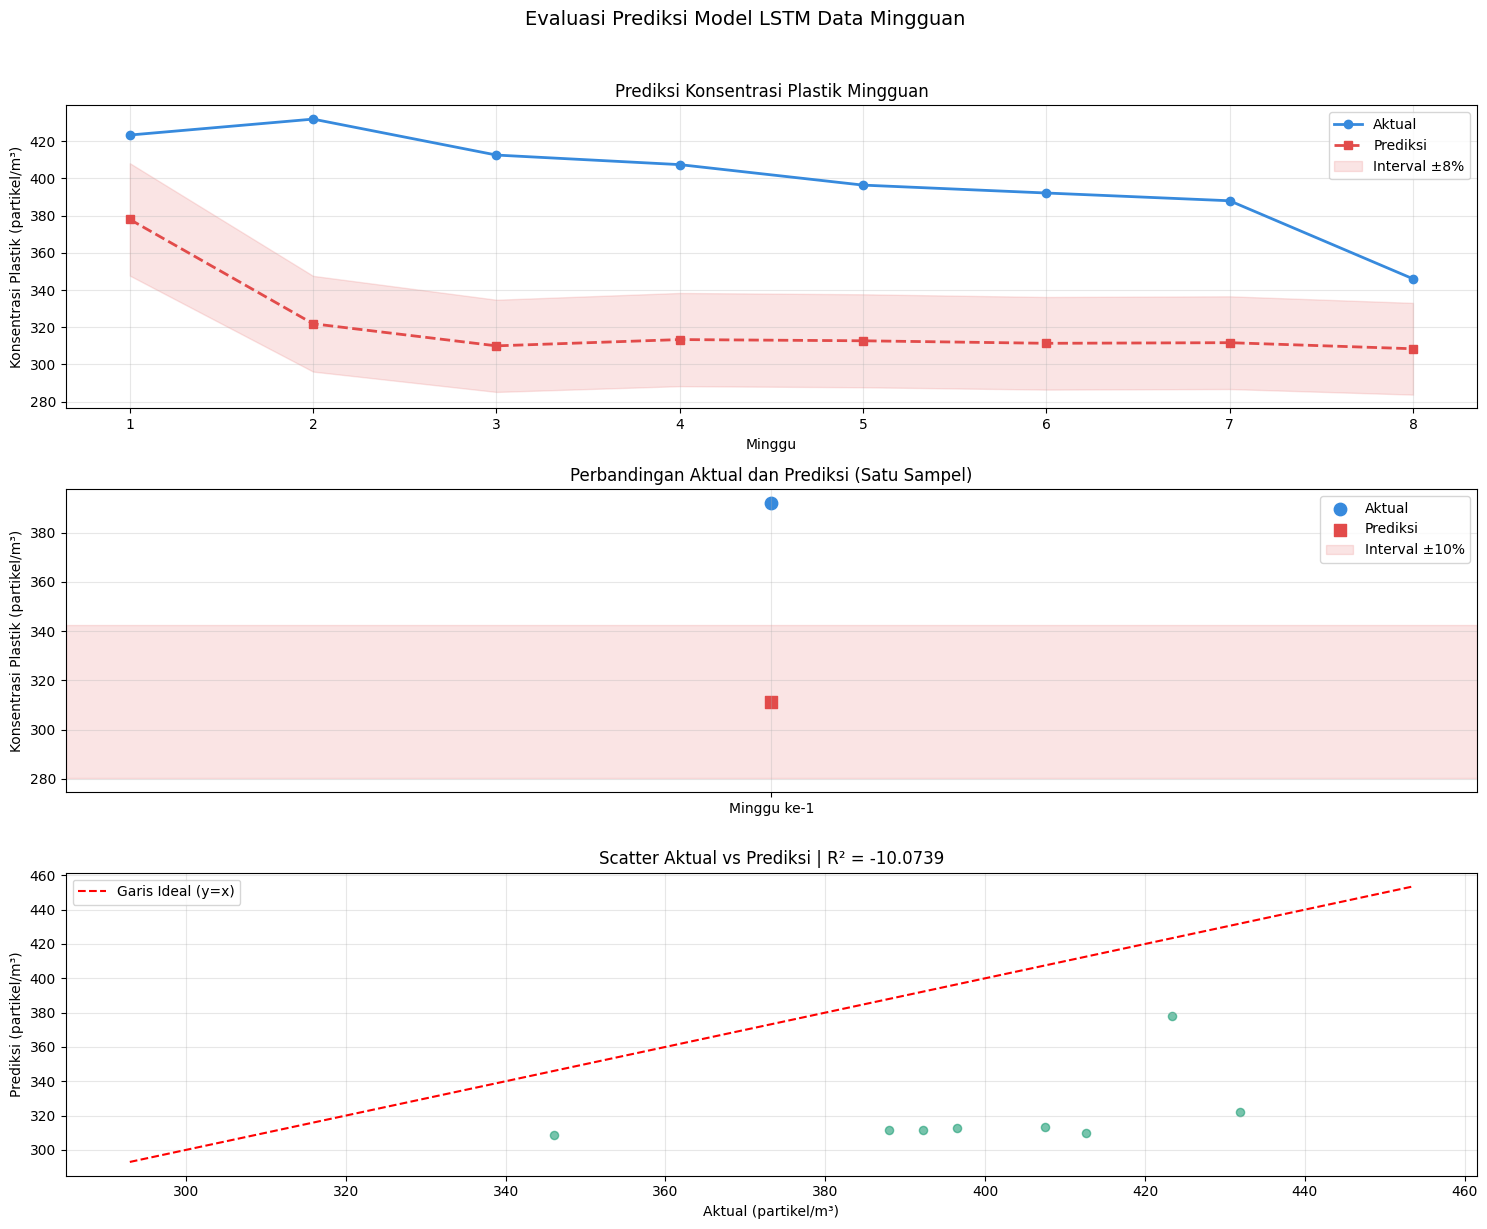

Visualisasi hasil prediksi selesai.


In [31]:
# ============================================================
# VISUALISASI HASIL PREDIKSI MODEL LSTM
# ============================================================

# Membuat kanvas berisi 3 grafik
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# ============================================================
# 1. GRAFIK HASIL PREDIKSI DATA MINGGUAN
# ============================================================

# Menentukan jumlah data yang akan ditampilkan
n_plot = min(12, len(y_true))

# Membuat sumbu x berupa minggu
minggu = np.arange(1, n_plot + 1)

# Mengambil data aktual dan prediksi
y_true_plot = y_true[:n_plot, 0]
y_pred_plot = y_pred[:n_plot, 0]

# Menampilkan data aktual
axes[0].plot(
    minggu,
    y_true_plot,
    marker='o',
    linewidth=2,
    color='#378ADD',
    label='Aktual'
)

# Menampilkan data prediksi
axes[0].plot(
    minggu,
    y_pred_plot,
    marker='s',
    linestyle='--',
    linewidth=2,
    color='#E24B4A',
    label='Prediksi'
)

# Menampilkan interval prediksi ±8%
axes[0].fill_between(
    minggu,
    y_pred_plot * 0.92,
    y_pred_plot * 1.08,
    color='#E24B4A',
    alpha=0.15,
    label='Interval ±8%'
)

axes[0].set_title(
    'Prediksi Konsentrasi Plastik Mingguan',
    fontsize=12
)

axes[0].set_xlabel('Minggu')

axes[0].set_ylabel('Konsentrasi Plastik (partikel/m³)')

axes[0].legend()

axes[0].grid(True, alpha=0.3)

# ============================================================
# 2. PERBANDINGAN SATU SAMPEL PREDIKSI
# ============================================================

contoh_idx = min(5, len(y_true)-1)

axes[1].scatter(
    1,
    y_true[contoh_idx,0],
    s=80,
    color='#378ADD',
    label='Aktual'
)

axes[1].scatter(
    1,
    y_pred[contoh_idx,0],
    s=80,
    color='#E24B4A',
    marker='s',
    label='Prediksi'
)

axes[1].fill_between(
    [0.8,1.2],
    y_pred[contoh_idx,0]*0.90,
    y_pred[contoh_idx,0]*1.10,
    color='#E24B4A',
    alpha=0.15,
    label='Interval ±10%'
)

axes[1].set_xlim(0.8,1.2)

axes[1].set_xticks([1])

axes[1].set_xticklabels(['Minggu ke-1'])

axes[1].set_title(
    'Perbandingan Aktual dan Prediksi (Satu Sampel)',
    fontsize=12
)

axes[1].set_ylabel('Konsentrasi Plastik (partikel/m³)')

axes[1].legend()

axes[1].grid(True, alpha=0.3)

# ============================================================
# 3. SCATTER AKTUAL VS PREDIKSI
# ============================================================

n_scatter = min(500, len(y_true_flat))

idx_scatter = np.random.choice(
    len(y_true_flat),
    n_scatter,
    replace=False
)

axes[2].scatter(
    y_true_flat[idx_scatter],
    y_pred_flat[idx_scatter],
    alpha=0.6,
    s=35,
    color='#1D9E75'
)

lim_min = min(
    y_true_flat.min(),
    y_pred_flat.min()
) * 0.95

lim_max = max(
    y_true_flat.max(),
    y_pred_flat.max()
) * 1.05

axes[2].plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    'r--',
    linewidth=1.5,
    label='Garis Ideal (y=x)'
)

axes[2].set_xlabel(
    'Aktual (partikel/m³)'
)

axes[2].set_ylabel(
    'Prediksi (partikel/m³)'
)

axes[2].set_title(
    f'Scatter Aktual vs Prediksi | R² = {r2:.4f}',
    fontsize=12
)

axes[2].legend()

axes[2].grid(True, alpha=0.3)

# ============================================================
# MENAMPILKAN DAN MENYIMPAN GAMBAR
# ============================================================

plt.suptitle(
    'Evaluasi Prediksi Model LSTM Data Mingguan',
    fontsize=14,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'hasil_prediksi_lstm_mingguan.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Visualisasi hasil prediksi selesai.')

## Sel 11 — Analisis Residual & Distribusi Error

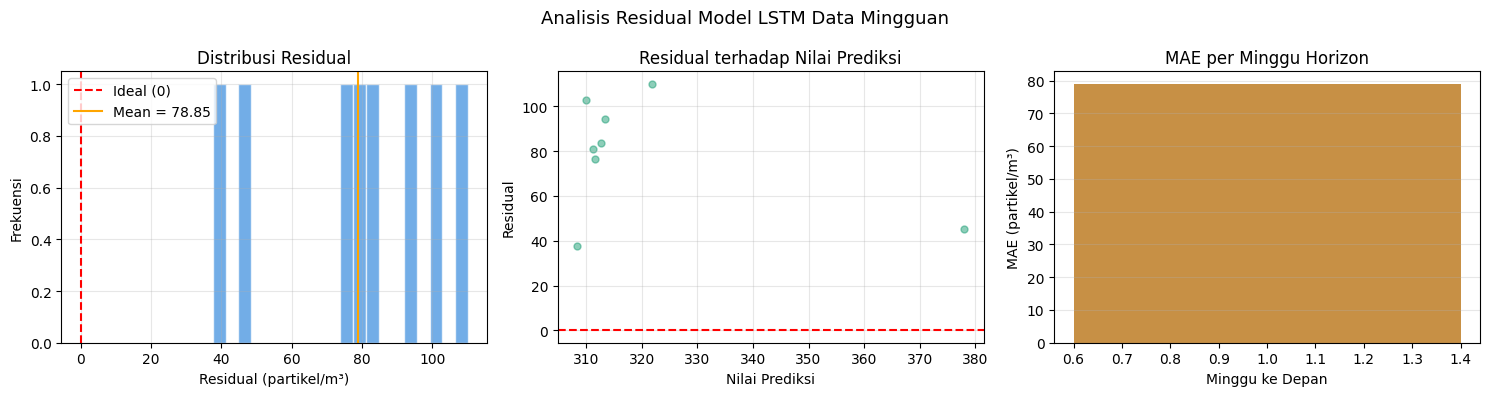


Statistik Residual
Mean Residual : 78.854
Standar Deviasi : 24.050
Residual Minimum : 37.641
Residual Maksimum : 110.089


In [33]:
# ============================================================
# ANALISIS RESIDUAL MODEL LSTM
# ============================================================

# Menghitung residual (selisih antara data aktual dan prediksi)
residual = y_true_flat - y_pred_flat

# Membuat kanvas berisi 3 grafik
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ============================================================
# 1. DISTRIBUSI RESIDUAL
# ============================================================

# Menampilkan histogram residual
axes[0].hist(
    residual,
    bins=20,
    color='#378ADD',
    alpha=0.7,
    edgecolor='white'
)

# Garis residual ideal
axes[0].axvline(
    0,
    color='red',
    linewidth=1.5,
    linestyle='--',
    label='Ideal (0)'
)

# Garis rata-rata residual
axes[0].axvline(
    residual.mean(),
    color='orange',
    linewidth=1.5,
    label=f'Mean = {residual.mean():.2f}'
)

axes[0].set_title('Distribusi Residual')

axes[0].set_xlabel('Residual (partikel/m³)')

axes[0].set_ylabel('Frekuensi')

axes[0].legend()

axes[0].grid(True, alpha=0.3)

# ============================================================
# 2. RESIDUAL VS HASIL PREDIKSI
# ============================================================

n_scatter = min(500, len(y_pred_flat))

idx_scatter = np.random.choice(
    len(y_pred_flat),
    n_scatter,
    replace=False
)

axes[1].scatter(
    y_pred_flat[idx_scatter],
    residual[idx_scatter],
    alpha=0.5,
    s=25,
    color='#1D9E75'
)

axes[1].axhline(
    0,
    color='red',
    linewidth=1.5,
    linestyle='--'
)

axes[1].set_title('Residual terhadap Nilai Prediksi')

axes[1].set_xlabel('Nilai Prediksi')

axes[1].set_ylabel('Residual')

axes[1].grid(True, alpha=0.3)

# ============================================================
# 3. MAE SETIAP MINGGU HORIZON
# ============================================================

mae_per_horizon = [

    mean_absolute_error(
        y_true[:, h],
        y_pred[:, h]
    )

    for h in range(HORIZON)

]

axes[2].bar(

    range(1, HORIZON + 1),

    mae_per_horizon,

    color='#BA7517',

    alpha=0.8

)

axes[2].set_title('MAE per Minggu Horizon')

axes[2].set_xlabel('Minggu ke Depan')

axes[2].set_ylabel('MAE (partikel/m³)')

axes[2].grid(True, alpha=0.3, axis='y')

# ============================================================
# MENAMPILKAN DAN MENYIMPAN GAMBAR
# ============================================================

plt.suptitle(
    'Analisis Residual Model LSTM Data Mingguan',
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    'analisis_residual_mingguan.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# MENAMPILKAN STATISTIK RESIDUAL
# ============================================================

print('\nStatistik Residual')

print('=' * 40)

print(f'Mean Residual : {residual.mean():.3f}')

print(f'Standar Deviasi : {residual.std():.3f}')

print(f'Residual Minimum : {residual.min():.3f}')

print(f'Residual Maksimum : {residual.max():.3f}')

print('=' * 40)

## Sel 12 — Fungsi Prediksi Real-Time (Inferensi)

Prediksi Konsentrasi Plastik Minggu Berikutnya
11-01-2026 : 309.82 partikel/m³   [SEDANG]


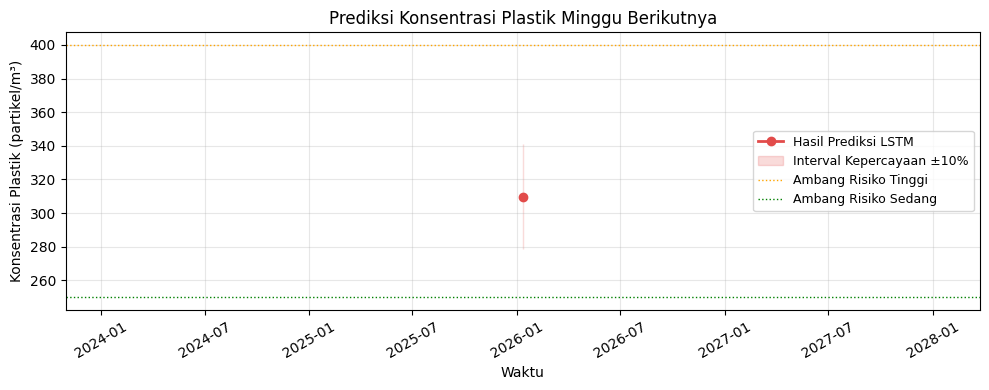


Visualisasi prediksi konsentrasi plastik mingguan berhasil dibuat.


In [35]:
# ============================================================
# FUNGSI PREDIKSI BERDASARKAN DATA TERBARU
# ============================================================

def prediksi_dari_data_terbaru(
    df_input,
    model,
    scaler_X,
    scaler_y,
    fitur_input,
    window=4,
    horizon=1
):
    """
    Melakukan prediksi konsentrasi plastik menggunakan
    data hidrodinamika mingguan terbaru.

    Parameter:
    - df_input      : DataFrame yang berisi data mingguan terbaru
    - model         : Model LSTM yang telah dilatih
    - scaler_X      : Scaler data input
    - scaler_y      : Scaler data target
    - fitur_input   : Daftar fitur yang digunakan
    - window        : Jumlah minggu yang dijadikan input
    - horizon       : Jumlah minggu yang akan diprediksi

    Mengembalikan:
    - prediksi       : Hasil prediksi konsentrasi plastik
    - waktu_prediksi : Waktu untuk setiap hasil prediksi
    """

    # ============================================================
    # MENGAMBIL DATA TERBARU
    # ============================================================

    # Mengambil sejumlah data terakhir sesuai ukuran window
    data_terbaru = df_input[fitur_input].values[-window:]

    # ============================================================
    # NORMALISASI DATA
    # ============================================================

    # Menormalisasi data menggunakan scaler yang sama
    # seperti saat proses pelatihan model
    data_ternormalisasi = scaler_X.transform(data_terbaru)

    # ============================================================
    # MENGUBAH BENTUK DATA
    # ============================================================

    # Mengubah bentuk data menjadi
    # (1, window, jumlah fitur)
    data_input = data_ternormalisasi.reshape(
        1,
        window,
        len(fitur_input)
    )

    # ============================================================
    # MELAKUKAN PREDIKSI
    # ============================================================

    # Melakukan prediksi menggunakan model LSTM
    hasil_prediksi_normal = model.predict(
        data_input,
        verbose=0
    )

    # Mengembalikan hasil prediksi ke skala asli
    hasil_prediksi = scaler_y.inverse_transform(
        hasil_prediksi_normal
    )[0]

    # ============================================================
    # MEMBUAT WAKTU PREDIKSI
    # ============================================================

    # Mengambil waktu terakhir pada dataset
    waktu_terakhir = df_input.index[-1]

    # Membuat waktu prediksi berdasarkan minggu berikutnya
    waktu_prediksi = pd.date_range(
        start=waktu_terakhir + pd.Timedelta(weeks=1),
        periods=horizon,
        freq='W'
    )

    # Mengembalikan hasil prediksi dan waktu prediksi
    return hasil_prediksi, waktu_prediksi


# ============================================================
# MELAKUKAN PREDIKSI MENGGUNAKAN DATA TERBARU
# ============================================================

hasil_prediksi, waktu_prediksi = prediksi_dari_data_terbaru(

    df_input=df_mingguan,

    model=model,

    scaler_X=scaler_X,

    scaler_y=scaler_y,

    fitur_input=FITUR_INPUT,

    window=WINDOW,

    horizon=HORIZON

)

# ============================================================
# MENAMPILKAN HASIL PREDIKSI
# ============================================================

print('=' * 55)
print('Prediksi Konsentrasi Plastik Minggu Berikutnya')
print('=' * 55)

for waktu, nilai in zip(waktu_prediksi, hasil_prediksi):

    if nilai > 400:
        tingkat_risiko = 'TINGGI'

    elif nilai > 250:
        tingkat_risiko = 'SEDANG'

    else:
        tingkat_risiko = 'RENDAH'

    print(
        f'{waktu.strftime("%d-%m-%Y")} : '
        f'{nilai:.2f} partikel/m³   [{tingkat_risiko}]'
    )

# ============================================================
# MEMBUAT VISUALISASI HASIL PREDIKSI
# ============================================================

# Membuat kanvas gambar
plt.figure(figsize=(10, 4))

# Menampilkan grafik hasil prediksi
plt.plot(

    waktu_prediksi,

    hasil_prediksi,

    marker='o',

    linewidth=2,

    color='#E24B4A',

    label='Hasil Prediksi LSTM'

)

# Menampilkan interval kepercayaan ±10%
plt.fill_between(

    waktu_prediksi,

    hasil_prediksi * 0.90,

    hasil_prediksi * 1.10,

    alpha=0.20,

    color='#E24B4A',

    label='Interval Kepercayaan ±10%'

)

# Menampilkan batas risiko tinggi
plt.axhline(

    400,

    color='orange',

    linewidth=1,

    linestyle=':',

    label='Ambang Risiko Tinggi'

)

# Menampilkan batas risiko sedang
plt.axhline(

    250,

    color='green',

    linewidth=1,

    linestyle=':',

    label='Ambang Risiko Sedang'

)

# Memberikan judul grafik
plt.title(
    'Prediksi Konsentrasi Plastik Minggu Berikutnya',
    fontsize=12
)

# Memberikan label sumbu X
plt.xlabel('Waktu')

# Memberikan label sumbu Y
plt.ylabel('Konsentrasi Plastik (partikel/m³)')

# Memutar label tanggal agar mudah dibaca
plt.xticks(rotation=30)

# Menampilkan legenda
plt.legend(fontsize=9)

# Menampilkan garis bantu (grid)
plt.grid(True, alpha=0.3)

# Mengatur tata letak grafik
plt.tight_layout()

# Menyimpan gambar hasil prediksi
plt.savefig(
    'prediksi_mingguan.png',
    dpi=150,
    bbox_inches='tight'
)

# Menampilkan grafik
plt.show()

# ============================================================
# MENAMPILKAN PESAN SELESAI
# ============================================================

print('\nVisualisasi prediksi konsentrasi plastik mingguan berhasil dibuat.')

## Sel 13 — Simpan Semua Hasil

In [37]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

# Mengimpor library JSON untuk menyimpan data
import json

# ============================================================
# MENYIMPAN MODEL LSTM
# ============================================================

# Menyimpan model LSTM yang telah dilatih
model.save('lstm_hidrodinamika_mingguan_final.h5')

print('Model berhasil disimpan:')
print('lstm_hidrodinamika_mingguan_final.h5')

# ============================================================
# MENYIMPAN DATASET MINGGUAN
# ============================================================

# Menyimpan dataset hidrodinamika mingguan ke file CSV
df_mingguan.to_csv('data_hidrodinamika_mingguan.csv')

print('Dataset berhasil disimpan:')
print('data_hidrodinamika_mingguan.csv')

# ============================================================
# MENYIMPAN RIWAYAT PELATIHAN MODEL
# ============================================================

# Mengubah riwayat pelatihan menjadi dictionary
riwayat_training = {
    nama: [float(nilai) for nilai in daftar_nilai]
    for nama, daftar_nilai in history.history.items()
}

# Menyimpan riwayat pelatihan ke file JSON
with open('riwayat_training.json', 'w') as file:
    json.dump(riwayat_training, file, indent=2)

print('Riwayat pelatihan berhasil disimpan:')
print('riwayat_training.json')

# ============================================================
# MENYIMPAN METRIK EVALUASI
# ============================================================

# Membuat dictionary metrik evaluasi
metrik_evaluasi = {
    'rmse_test'     : float(rmse),
    'mae_test'      : float(mae),
    'mape_test'     : float(mape),
    'r2_test'       : float(r2),
    'window'        : WINDOW,
    'horizon'       : HORIZON,
    'jumlah_fitur'  : n_fitur,
    'fitur_input'   : FITUR_INPUT
}

# Menyimpan metrik evaluasi ke file JSON
with open('metrik_evaluasi.json', 'w') as file:
    json.dump(metrik_evaluasi, file, indent=2)

print('Metrik evaluasi berhasil disimpan:')
print('metrik_evaluasi.json')

# ============================================================
# INFORMASI PENYIMPANAN KE GOOGLE DRIVE
# ============================================================

print('\nApabila ingin menyimpan seluruh file ke Google Drive,')
print('jalankan sel penyimpanan Google Drive setelah sel ini.')

# ============================================================
# MENAMPILKAN RINGKASAN AKHIR
# ============================================================

print('\n' + '=' * 60)
print('RINGKASAN AKHIR MODEL LSTM')
print('=' * 60)

print(f'Model            : Bidirectional LSTM (32 → 16 → 8)')
print(f'Dataset          : {df_mingguan.shape[0]} minggu')
print(f'Fitur Input      : {n_fitur} variabel')
print(f'Window           : {WINDOW} minggu')
print(f'Horizon          : {HORIZON} minggu ke depan')

print('\nHasil Evaluasi Model')
print(f'RMSE             : {rmse:.2f} partikel/m³')
print(f'MAE              : {mae:.2f} partikel/m³')
print(f'MAPE             : {mape:.2f}%')
print(f'R²               : {r2:.4f}')

print('=' * 60)
print('Seluruh proses pelatihan, evaluasi, dan penyimpanan model telah selesai.')

Model berhasil disimpan:
lstm_hidrodinamika_mingguan_final.h5
Dataset berhasil disimpan:
data_hidrodinamika_mingguan.csv
Riwayat pelatihan berhasil disimpan:
riwayat_training.json
Metrik evaluasi berhasil disimpan:
metrik_evaluasi.json

Apabila ingin menyimpan seluruh file ke Google Drive,
jalankan sel penyimpanan Google Drive setelah sel ini.

RINGKASAN AKHIR MODEL LSTM
Model            : Bidirectional LSTM (32 → 16 → 8)
Dataset          : 53 minggu
Fitur Input      : 11 variabel
Window           : 4 minggu
Horizon          : 1 minggu ke depan

Hasil Evaluasi Model
RMSE             : 82.44 partikel/m³
MAE              : 78.85 partikel/m³
MAPE             : 19.56%
R²               : -10.0739
Seluruh proses pelatihan, evaluasi, dan penyimpanan model telah selesai.


In [38]:
# ===== SIMPAN KE GOOGLE DRIVE (OPSIONAL) =====
from google.colab import drive
drive.mount('/content/drive')

import shutil
folder = '/content/drive/MyDrive/LSTM_Plastik_Hidrodinamika'
os.makedirs(folder, exist_ok=True)

for file in [
    'lstm_hidrodinamika_final.h5',
    'lstm_hidrodinamika_terbaik.h5',
    'data_hidrodinamika_sintetis.csv',
    'training_history.json',
    'metrik_evaluasi.json',
    'eda_hidrodinamika.png',
    'kurva_training.png',
    'hasil_prediksi_lstm.png',
    'analisis_residual.png',
    'prediksi_24jam.png',
]:
    if os.path.exists(file):
        shutil.copy(file, f'{folder}/{file}')
        print(f'Tersimpan: {folder}/{file}')

print('\nSemua file berhasil disimpan ke Google Drive!')

Mounted at /content/drive
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/lstm_hidrodinamika_final.h5
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/lstm_hidrodinamika_terbaik.h5
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/data_hidrodinamika_sintetis.csv
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/training_history.json
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/metrik_evaluasi.json
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/eda_hidrodinamika.png
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/kurva_training.png
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/analisis_residual.png
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/prediksi_24jam.png

Semua file berhasil disimpan ke Google Drive!
